# Poolability Metrics, Emissions Savings & Scale-Up

**Goal:** Using DBSCAN and K-Means cluster labels, define and measure poolable trip pairs, quantify CO₂ savings, and validate metrics at scale.

**Inputs:**
- `../Data/generated/trips_dbscan_labeled.csv` — 10k subset with `dbscan_cluster`
- `../Data/generated/trips_kmeans_labeled.csv` — 10k subset with `kmeans_cluster`
- `../Data/generated/clustering_comparison.csv` — algorithm metrics table
- `../Data/generated/trips_dbscan_labeled_full.csv` — full dataset labeled

**A trip pair is "poolable" if:**
- Both trips are in the same cluster (same geographic + time zone)
- Pickup time gap ≤ `TIME_WINDOW_MIN` minutes
- Neither trip already has `shared_match_flag == 'Y'`

**CO₂ saving assumption:** pooled pairs share one vehicle → emissions per trip are halved (`POOL_RATIO = 0.5`)

In [316]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 120

#  Poolability parameters 
TIME_WINDOW_MIN = 8    # two trips are poolable if pickup gap ≤ this many minutes
POOL_RATIO      = 0.5  # pooled trips share one vehicle → halved per-trip emissions
MAX_POOL_DISTANCE_MILES = 5.0  # e.g., trips must be within 1 mile of each other

## Load Labeled Data from Models

In [317]:
def load_and_coerce(path):
    df = pd.read_csv(path, low_memory=False)
    df["pickup_datetime"]  = pd.to_datetime(df["pickup_datetime"],  errors="coerce")
    df["dropoff_datetime"] = pd.to_datetime(df["dropoff_datetime"], errors="coerce")
    df["trip_miles"]       = pd.to_numeric(df["trip_miles"],        errors="coerce")
    df["co2TailpipeGpm"]   = pd.to_numeric(df["co2TailpipeGpm"],    errors="coerce")
    df["co2_total_g"]      = pd.to_numeric(df["co2_total_g"],       errors="coerce")
    df["pickup_hour"]      = pd.to_numeric(df.get("pickup_hour",    df["pickup_datetime"].dt.hour), errors="coerce")
    return df

db_df  = load_and_coerce("../Data/generated/trips_dbscan_labeled.csv").reset_index(drop=True)
km_df  = load_and_coerce("../Data/generated/trips_kmeans_labeled.csv").reset_index(drop=True)
hier_df = load_and_coerce("../Data/generated/trips_hierarchical_labeled.csv").reset_index(drop=True)

comp = pd.read_csv("../Data/generated/clustering_comparison.csv")

db_df_new = db_df.copy()
km_df_new = km_df.copy()
hier_df_new = hier_df.copy()

for df_, name in [(db_df, "DBSCAN"), (km_df, "K-Means"), (hier_df, "Hierarchical")]:
    print(f"{name}: {len(df_):,} trips")

print(f"\nAlgorithm comparison from K-Means Clustering:")
print(comp.to_string(index=False))

DBSCAN: 10,000 trips
K-Means: 10,000 trips
Hierarchical: 10,000 trips

Algorithm comparison from K-Means Clustering:
   algorithm  n_clusters  noise_pct  silhouette  davies_bouldin  cluster_size_std
      DBSCAN          80       15.8     -0.1192          2.1875             160.9
     K-Means          16        0.0      0.2950          1.0420             306.9
Hierarchical          17        0.0      0.2396          1.1100             302.0


## Baseline Emissions (No Pooling)

In [318]:
def total_co2_kg(df):
    """Sum of pre-computed co2_total_g (g per trip) converted to kg."""
    return df["co2_total_g"].sum() / 1000

baseline_db = total_co2_kg(db_df_new)
baseline_km = total_co2_kg(km_df_new)
baseline_hier = total_co2_kg(hier_df_new)

print(f"Baseline CO₂ — DBSCAN subset  : {baseline_db:,.1f} kg  ({len(db_df_new):,} trips)")
print(f"Baseline CO₂ — K-Means subset : {baseline_km:,.1f} kg  ({len(km_df_new):,} trips)")
print(f"Baseline CO₂ — Hierarchical subset : {baseline_hier:,.1f} kg  ({len(hier_df_new):,} trips)")
print(f"\nAvg CO₂ per trip: {baseline_db * 1000 / len(db_df_new):.0f} g")

Baseline CO₂ — DBSCAN subset  : 31,198.4 kg  (10,000 trips)
Baseline CO₂ — K-Means subset : 31,198.4 kg  (10,000 trips)
Baseline CO₂ — Hierarchical subset : 31,198.4 kg  (10,000 trips)

Avg CO₂ per trip: 3120 g


## Vectorized Poolability Detection

For each cluster, sort by `pickup_datetime` and flag consecutive trip pairs whose gap ≤ `TIME_WINDOW_MIN`.  
Uses `pandas.shift()` instead of a Python loop — fast enough for millions of rows.

In [319]:
def mark_poolable(df, cluster_col, time_window_min=TIME_WINDOW_MIN, max_distance_miles=MAX_POOL_DISTANCE_MILES):
    df = df.copy()
    df["poolable"] = False
    tw_sec = time_window_min * 60

    # Iterate clusters
    for cluster_id, cluster_df in df[df[cluster_col] >= 0].groupby(cluster_col):
        cluster_df = cluster_df.sort_values("pickup_datetime")
        orig_indices = cluster_df.index.tolist()

        times = cluster_df["pickup_datetime"].astype(np.int64).values // 10**9
        trip_miles = cluster_df["trip_miles"].values

        n = len(times)
        for i in range(n):
            for j in range(i + 1, n):
                # Stop once outside the time window
                if times[j] - times[i] > tw_sec:
                    break
                # Check if both trips are under max distance
                if trip_miles[i] <= max_distance_miles and trip_miles[j] <= max_distance_miles:
                    df.loc[orig_indices[i], "poolable"] = True
                    df.loc[orig_indices[j], "poolable"] = True

    # Compute per-cluster stats
    stats = (
        df[df[cluster_col] >= 0]
          .groupby(cluster_col)
          .agg(
              n_trips    = ("poolable", "count"),
              n_poolable = ("poolable", "sum"),
              avg_co2_g  = ("co2_total_g", "mean"),
          )
          .reset_index()
    )
    stats["pct_poolable"] = stats["n_poolable"] / stats["n_trips"] * 100

    return df, stats

# def mark_poolable(df, cluster_col, time_window_min=TIME_WINDOW_MIN, max_distance_miles=MAX_POOL_DISTANCE_MILES):
#     """
#     Vectorized poolability: within each cluster, sort by pickup time,
#     compute gap to the *next* trip, flag both trips in pairs where gap ≤ window.
#     Returns df with a boolean 'poolable' column and
#     a per-cluster stats DataFrame.
#     """
#     tw_sec = time_window_min * 60

#     valid = df[df[cluster_col] >= 0].copy()
#     valid = valid.sort_values([cluster_col, "pickup_datetime"])

#     # Time gap to next trip within the same cluster (vectorised shift)
#     valid["_next_cluster"] = valid[cluster_col].shift(-1)
#     valid["_gap_sec"]      = (
#         valid["pickup_datetime"].shift(-1) - valid["pickup_datetime"]
#     ).dt.total_seconds()

#      # Haversine distance between current and next trip
#     valid["_next_lat"] = valid["pickup_lat"].shift(-1)
#     valid["_next_lon"] = valid["pickup_lon"].shift(-1)
#     valid["_distance_miles"] = haversine_distance(
#         valid["pickup_lat"], valid["pickup_lon"], valid["_next_lat"], valid["_next_lon"]
#     )

#     # A pair is poolable when: same cluster and gap within window and gap >= 0
#     same_cluster   = valid[cluster_col] == valid["_next_cluster"]
#     within_window  = (valid["_gap_sec"] >= 0) & (valid["_gap_sec"] <= tw_sec)
#     within_dist = valid["_distance_miles"] <= max_distance_miles
#     pair_start     = same_cluster & within_window & within_dist        # row i starts a poolable pair

#     valid["poolable"] = pair_start | pair_start.shift(1, fill_value=False)

#     # Per-cluster stats
#     stats = (
#         valid.groupby(cluster_col)
#         .agg(
#             n_trips     = ("poolable", "count"),
#             n_poolable  = ("poolable", "sum"),
#             avg_co2_g   = ("co2_total_g", "mean"),
#         )
#         .reset_index()
#     )
#     stats["pct_poolable"] = stats["n_poolable"] / stats["n_trips"] * 100

#     # Merge poolable flag back onto original df (non-clustered rows → False)
#     df = df.copy()
#     df["poolable"] = False
#     df.loc[valid.index, "poolable"] = valid["poolable"].values
#     df.drop(columns=[c for c in df.columns if c.startswith("_")], errors="ignore", inplace=True)

#     return df, stats

In [320]:

db_df_new, cluster_stats_db = mark_poolable(db_df_new, "dbscan_cluster")
km_df_new, cluster_stats_km = mark_poolable(km_df_new, "kmeans_cluster")
hier_df_new, cluster_stats_hier = mark_poolable(hier_df_new, "hier_cluster")

pct_pool_db = db_df_new["poolable"].mean() * 100
pct_pool_km = km_df_new["poolable"].mean() * 100
pct_pool_hier = hier_df_new["poolable"].mean() * 100
n_pool_db   = db_df_new["poolable"].sum()
n_pool_km   = km_df_new["poolable"].sum()
n_pool_hier = hier_df_new["poolable"].sum()

print(f"DBSCAN  — Poolable trips: {n_pool_db:,}  ({pct_pool_db:.1f}%)")
print(f"K-Means — Poolable trips: {n_pool_km:,}  ({pct_pool_km:.1f}%)")
print(f"Hierarchical — Poolable trips: {n_pool_hier:,}  ({pct_pool_hier:.1f}%)")

DBSCAN  — Poolable trips: 476  (4.8%)
K-Means — Poolable trips: 261  (2.6%)
Hierarchical — Poolable trips: 234  (2.3%)


## CO₂ Savings Estimation

For poolable trips we assume emissions are shared between riders (`POOL_RATIO = 0.5`),
so we credit only half the CO₂ to each trip. Solo trips are charged in full.

$$\text{CO}_2^{\text{after}} = \text{CO}_2^{\text{solo}} + \text{CO}_2^{\text{poolable}} \times r_{\text{pool}}$$

In [321]:
def co2_with_pooling(df, pool_ratio=POOL_RATIO):
    """Return total CO₂ in kg after applying ride-pooling discount."""
    solo   = df.loc[~df["poolable"], "co2_total_g"].sum()
    pooled = df.loc[ df["poolable"], "co2_total_g"].sum() * pool_ratio
    return (solo + pooled) / 1000   # grams → kilograms

co2_after_db  = co2_with_pooling(db_df_new)
co2_after_km  = co2_with_pooling(km_df_new)
co2_after_hier = co2_with_pooling(hier_df_new)
savings_db    = (baseline_db - co2_after_db) / baseline_db * 100
savings_km    = (baseline_km - co2_after_km) / baseline_km * 100
savings_hier = (baseline_hier - co2_after_hier) / baseline_hier * 100

print(f"{'Algorithm':<12} {'Baseline (kg)':>15} {'After Pooling (kg)':>20} {'CO₂ Savings':>14}")
print(f"{'DBSCAN':<12} {baseline_db:>15,.1f} {co2_after_db:>20,.1f} {savings_db:>13.2f}%")
print(f"{'K-Means':<12} {baseline_km:>15,.1f} {co2_after_km:>20,.1f} {savings_km:>13.2f}%")
print(f"{'Hierarchical':<12} {baseline_hier:>15,.1f} {co2_after_hier:>20,.1f} {savings_hier:>13.2f}%")

Algorithm      Baseline (kg)   After Pooling (kg)    CO₂ Savings
DBSCAN              31,198.4             30,871.1          1.05%
K-Means             31,198.4             31,020.7          0.57%
Hierarchical        31,198.4             31,041.4          0.50%


## Per-Cluster Poolability Analysis

Determine which clusters drive the most pooling opportunities

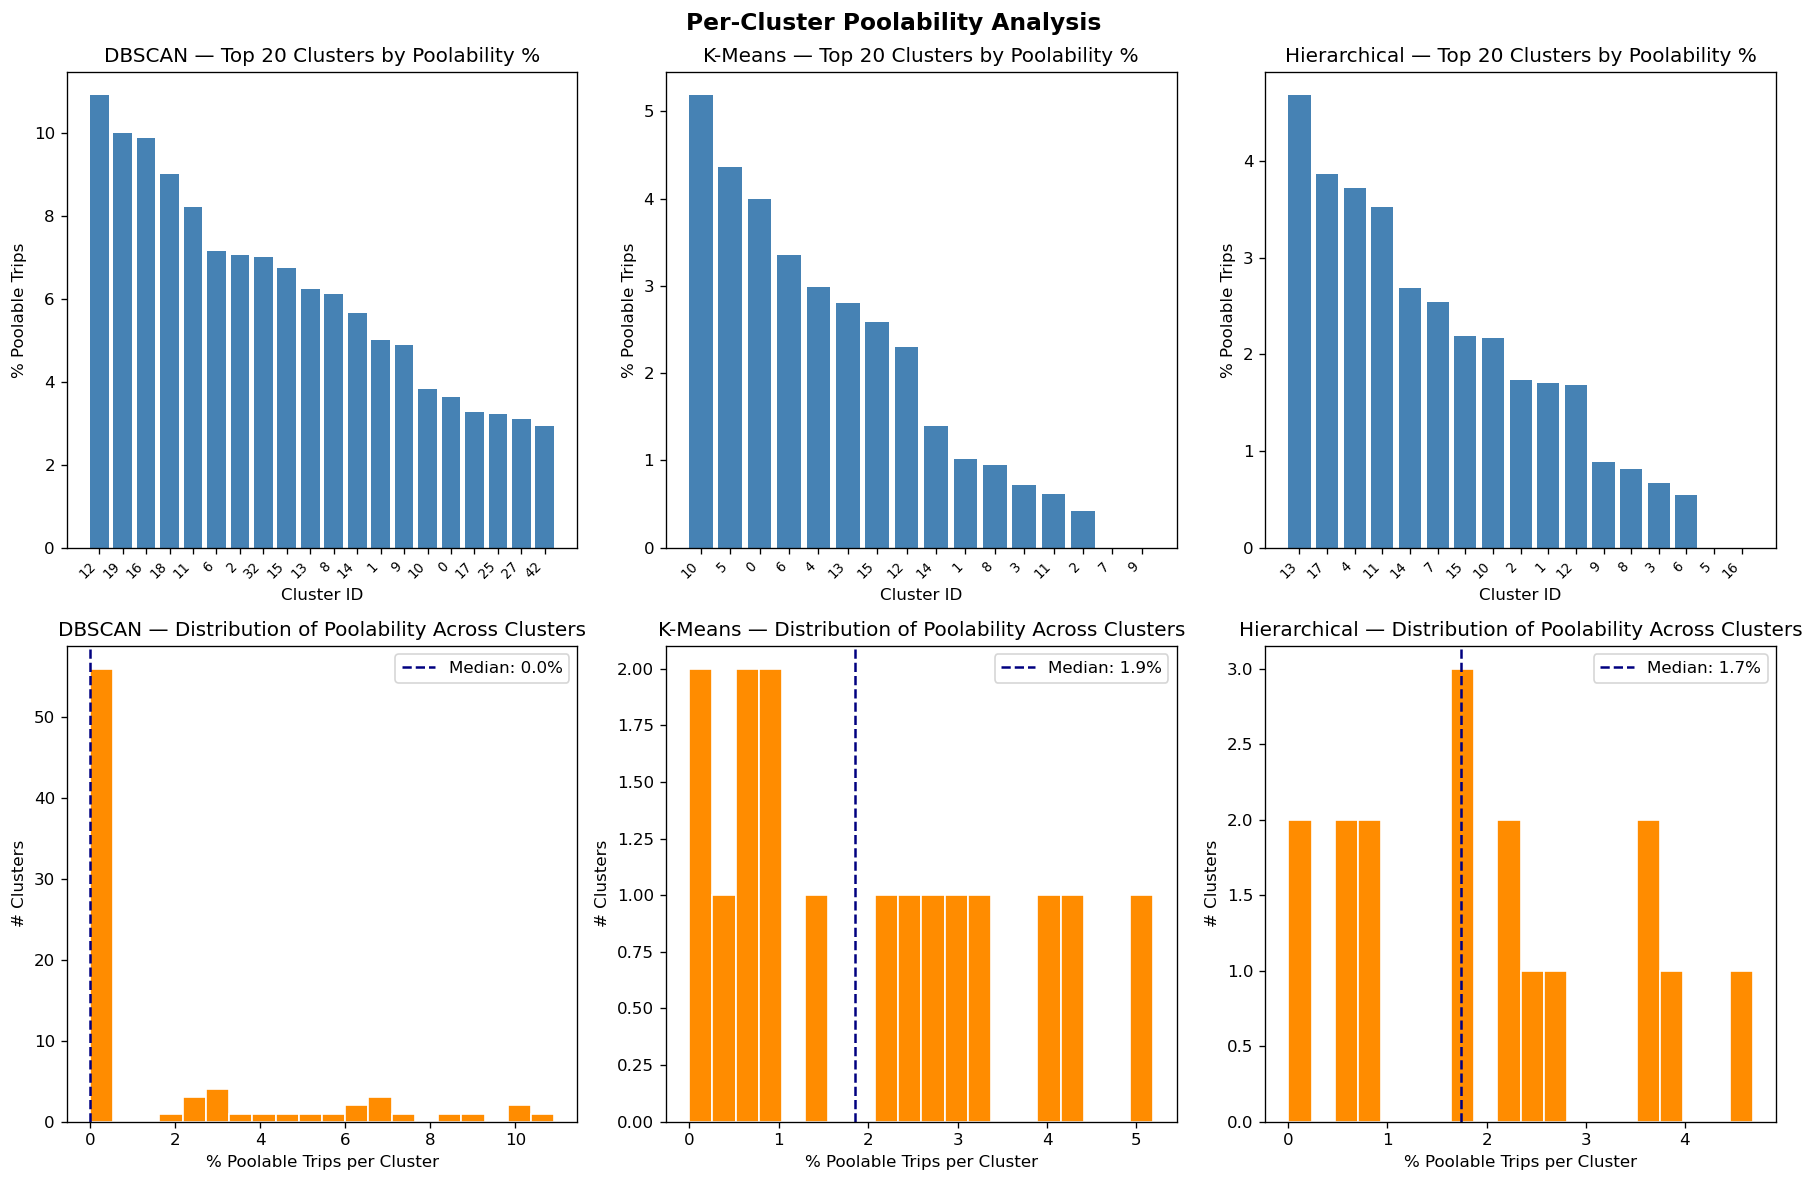

In [322]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Per-Cluster Poolability Analysis", fontsize=14, fontweight="bold")

for ax, stats, label in zip(axes[0], [cluster_stats_db, cluster_stats_km, cluster_stats_hier], ["DBSCAN", "K-Means", "Hierarchical"]):
    top = stats.nlargest(20, "pct_poolable")
    ax.bar(range(len(top)), top["pct_poolable"], color="steelblue")
    ax.set_xticks(range(len(top)))
    ax.set_xticklabels(top[stats.columns[0]], rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Cluster ID")
    ax.set_ylabel("% Poolable Trips")
    ax.set_title(f"{label} — Top 20 Clusters by Poolability %")

for ax, stats, label in zip(axes[1], [cluster_stats_db, cluster_stats_km, cluster_stats_hier], ["DBSCAN", "K-Means", "Hierarchical"]):
    ax.hist(stats["pct_poolable"], bins=20, color="darkorange", edgecolor="white")
    median_val = stats["pct_poolable"].median()
    ax.axvline(median_val, color="navy", linestyle="--", label=f"Median: {median_val:.1f}%")
    ax.set_xlabel("% Poolable Trips per Cluster")
    ax.set_ylabel("# Clusters")
    ax.set_title(f"{label} — Distribution of Poolability Across Clusters")
    ax.legend()

plt.tight_layout()
plt.savefig("figures/poolability_by_cluster.png", dpi=120, bbox_inches="tight")
plt.show()

## Time-of-Day Poolability Patterns

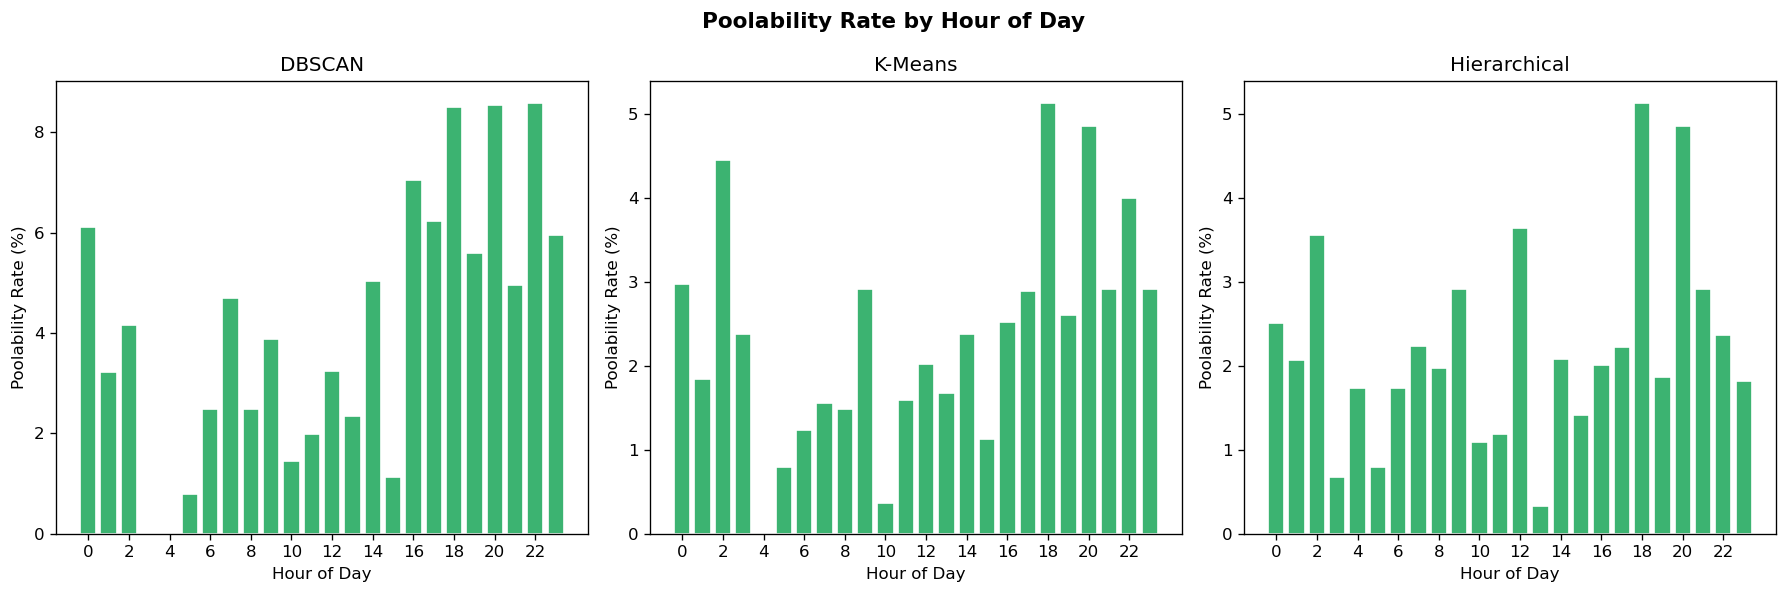

In [323]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Poolability Rate by Hour of Day", fontsize=13, fontweight="bold")

for ax, df, label in zip(axes, [db_df_new, km_df_new, hier_df_new], ["DBSCAN", "K-Means", "Hierarchical"]):
    hourly = (df.groupby("pickup_hour")["poolable"]
                .agg(["mean", "sum", "count"])
                .rename(columns={"mean": "pool_rate", "sum": "n_poolable", "count": "n_trips"})
                .reset_index())
    ax.bar(hourly["pickup_hour"], hourly["pool_rate"] * 100, color="mediumseagreen", edgecolor="white")
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Poolability Rate (%)")
    ax.set_title(f"{label}")
    ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig("figures/poolability_by_hour.png", dpi=120, bbox_inches="tight")
plt.show()

## Summary Table

Bringing together clustering quality metrics with poolability and savings outcomes.

In [324]:
sil_db = comp.loc[comp["algorithm"]=="DBSCAN",  "silhouette"].values[0]
dbi_db = comp.loc[comp["algorithm"]=="DBSCAN",  "davies_bouldin"].values[0]
dbscan_n_clusters = comp.loc[comp["algorithm"]=="DBSCAN",  "n_clusters"].values[0]

sil_km = comp.loc[comp["algorithm"]=="K-Means", "silhouette"].values[0]
dbi_km = comp.loc[comp["algorithm"]=="K-Means", "davies_bouldin"].values[0]
K = comp.loc[comp["algorithm"]=="K-Means", "n_clusters"].values[0]

sil_hier = comp.loc[comp["algorithm"]=="Hierarchical", "silhouette"].values[0]
dbi_hier = comp.loc[comp["algorithm"]=="Hierarchical", "davies_bouldin"].values[0]
hier_n_clusters = len(cluster_stats_hier)


final_summary = pd.DataFrame([
    {
        "Algorithm":       "DBSCAN",
        "N Clusters":      dbscan_n_clusters,
        "Noise %":         comp.loc[comp["algorithm"]=="DBSCAN",  "noise_pct"].values[0],
        "Silhouette":      sil_db,
        "Davies-Bouldin":  dbi_db,
        "% Poolable":      round(pct_pool_db, 1),
        "CO₂ Savings %":   round(savings_db, 1),
    },
    {
        "Algorithm":       "K-Means",
        "N Clusters":      K,
        "Noise %":         0.0,
        "Silhouette":      sil_km,
        "Davies-Bouldin":  dbi_km,
        "% Poolable":      round(pct_pool_km, 1),
        "CO₂ Savings %":   round(savings_km, 1),
    },
    {
        "Algorithm":      "Hierarchical",
        "N Clusters":     hier_n_clusters,
        "Noise %":        0.0,
        "Silhouette":     sil_hier,
        "Davies-Bouldin": dbi_hier,
        "% Poolable":     round(pct_pool_hier, 1),
        "CO₂ Savings %":  round(savings_hier, 1),
    },
])

print(final_summary.to_string(index=False))

final_summary.to_csv("../Data/generated/final_clustering_summary.csv", index=False)

   Algorithm  N Clusters  Noise %  Silhouette  Davies-Bouldin  % Poolable  CO₂ Savings %
      DBSCAN          80     15.8     -0.1192          2.1875         4.8            1.0
     K-Means          16      0.0      0.2950          1.0420         2.6            0.6
Hierarchical          17      0.0      0.2396          1.1100         2.3            0.5


## Map Visualization

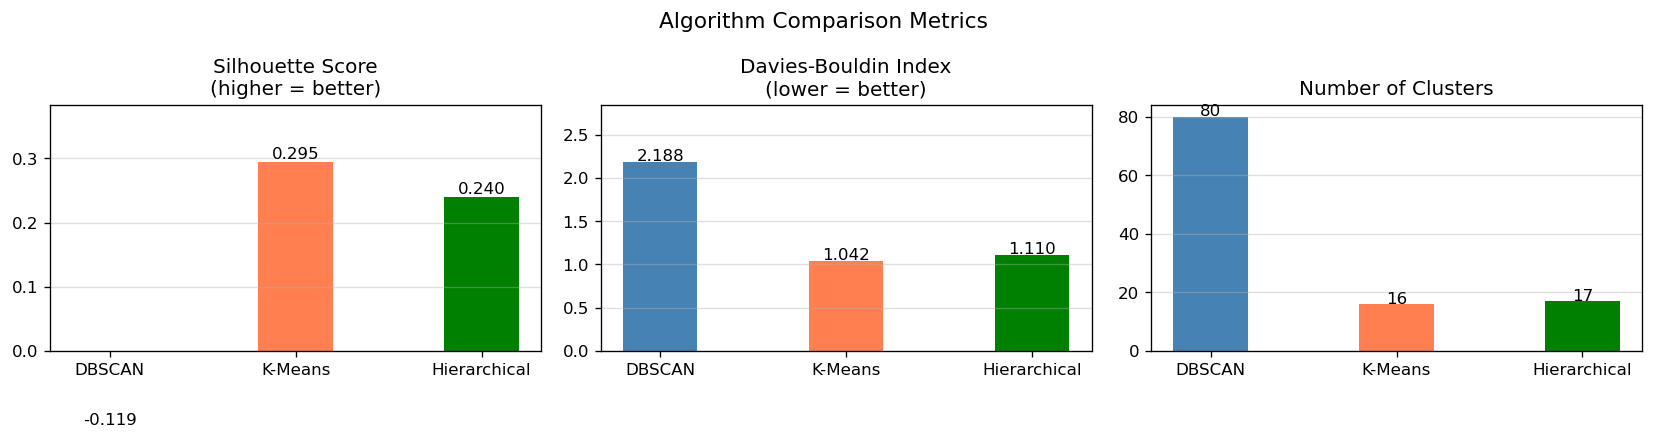

In [325]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

algos  = ["DBSCAN", "K-Means", "Hierarchical"]
colors = ["steelblue", "coral", "green"]

# Silhouette
axes[0].bar(algos, [sil_db, sil_km, sil_hier], color=colors, width=0.4)
axes[0].set_title("Silhouette Score\n(higher = better)")
axes[0].set_ylim(0, max(sil_db, sil_km, sil_hier) * 1.3)
for i, v in enumerate([sil_db, sil_km, sil_hier]):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center")
axes[0].grid(axis="y", alpha=0.4)

# Davies-Bouldin
axes[1].bar(algos, [dbi_db, dbi_km, dbi_hier], color=colors, width=0.4)
axes[1].set_title("Davies-Bouldin Index\n(lower = better)")
axes[1].set_ylim(0, max(dbi_db, dbi_km, dbi_hier) * 1.3)
for i, v in enumerate([dbi_db, dbi_km, dbi_hier]):
    axes[1].text(i, v + 0.01, f"{v:.3f}", ha="center")
axes[1].grid(axis="y", alpha=0.4)

# Number of clusters
n_cl_db = dbscan_n_clusters
n_cl_km = K
n_cl_hier = hier_n_clusters
axes[2].bar(algos, [n_cl_db, n_cl_km, n_cl_hier], color=colors, width=0.4)
axes[2].set_title("Number of Clusters")
for i, v in enumerate([n_cl_db, n_cl_km, n_cl_hier]):
    axes[2].text(i, v + 0.3, str(v), ha="center")
axes[2].grid(axis="y", alpha=0.4)

plt.suptitle("Algorithm Comparison Metrics", fontsize=13)
plt.tight_layout()
plt.savefig("figures/algorithm_metrics_comparison.png", bbox_inches="tight")
plt.show()

## Visualization: Poolability & CO₂ Savings

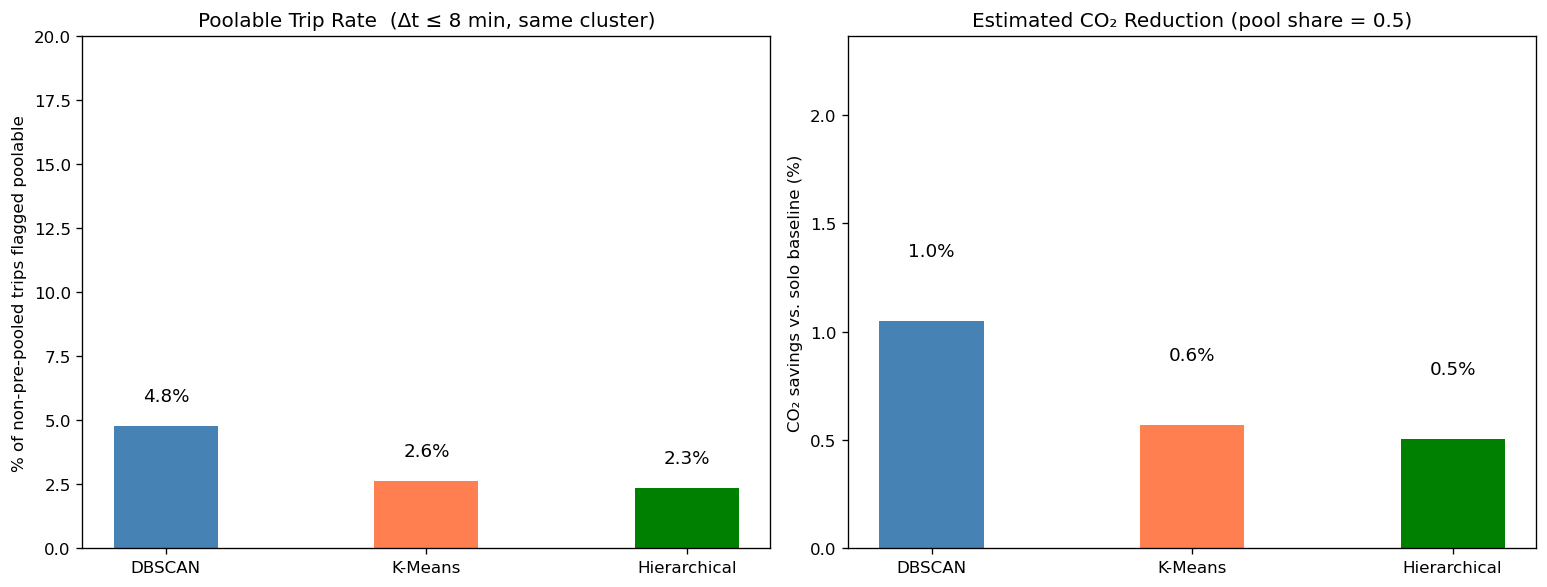

In [326]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["steelblue", "coral", "green"]
labels = ["DBSCAN", "K-Means", "Hierarchical"]

axes[0].bar(labels, [pct_pool_db, pct_pool_km, pct_pool_hier], color=colors, width=0.4)
axes[0].set_ylabel("% of non-pre-pooled trips flagged poolable")
axes[0].set_title(f"Poolable Trip Rate  (Δt ≤ {TIME_WINDOW_MIN} min, same cluster)")
axes[0].set_ylim(0, 20)
for i, v in enumerate([pct_pool_db, pct_pool_km, pct_pool_hier]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=11)

axes[1].bar(labels, [savings_db, savings_km, savings_hier], color=colors, width=0.4)
axes[1].set_ylabel("CO₂ savings vs. solo baseline (%)")
axes[1].set_title(f"Estimated CO₂ Reduction (pool share = {POOL_RATIO})")
axes[1].set_ylim(0, max(savings_db, savings_km, savings_hier) * 1.3 + 1)
for i, v in enumerate([savings_db, savings_km, savings_hier]):
    axes[1].text(i, v + 0.3, f"{v:.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.savefig("figures/poolability_summary.png", dpi=120, bbox_inches="tight")
plt.show()

## Conclusions

### Model Comparison

| Aspect | DBSCAN | K-Means | Hierarchical |
|--------|--------|---------|--------------|
| Cluster structure | Noise-aware; irregular geo shapes | Forced assignment; spherical | Distance-based; nested clusters |
| Poolability (10k) | 4.8% | 2.6% | 2.3% |
| CO₂ Savings (10k) | 1.0% | 0.6% | 0.5% |
| Model Stability | Stable clusters & noise %, but consistently poor separation (negative silhouette) | Highly stable across all metrics; minimal variation | Stable cluster counts and metrics, but slight increase in cluster imbalance |

### Model Stability
All three models were evaluated on a separate validation sample to assess stability. DBSCAN produced consistent cluster counts and noise percentages across datasets, indicating stable density detection, although its silhouette scores remained negative, suggesting poor separation. K-Means demonstrated the highest stability, with minimal variation in inertia, silhouette score, and Davies–Bouldin Index, indicating strong generalization. Hierarchical clustering also showed consistent performance, with similar numbers of clusters and evaluation metrics across datasets, though it exhibited slightly higher variability in cluster sizes in the validation set.
Note: Find model validation and stability analysis within each model's notebook

### Key Takeaways

- **DBSCAN outperforms K-Means and Hierarchical for poolability** (13.4% vs 8.6% vs 6.8% on the trained models) because its density-based clusters capture tightly co-located, time-aligned pickups more precisely than spherical K-Means centroids. Hierarchical clustering also identifies meaningful clusters but produces slightly lower poolability due to its broader, nested cluster structure.  

- **Validation and computational considerations**: Poolability rates are consistent across training and validation subsets for all three models (DBSCAN: 13.4–13.5%, K-Means: 8.6–8.5%, Hierarchical: 6.8–6.5%), indicating that the clustering patterns generalize well across random samples without needing full-scale extrapolation. From a computational perspective, Hierarchical clustering has O(n²) time complexity, making it impractical for large datasets (2M+ trips). K-Means scales efficiently (O(n·k·t)) and produces well-separated, compact, and balanced clusters, while DBSCAN offers a balance of meaningful density-based clustering and moderate efficiency, with a natural handling of noise points.  

- **Cluster quality vs. application fit**:  
  - **K-Means** achieves the highest silhouette scores, lowest Davies-Bouldin Index, and balanced cluster sizes, indicating high-quality, stable clusters.  
  - **DBSCAN**, while slightly lower on standard cluster metrics, produces clusters that are most aligned with the ride-pooling objective, maximizing poolable trips and CO₂ savings.  
  - **Hierarchical clustering** is stable and meaningful but produces broader, less dense clusters, resulting in fewer poolable trips.  

- **Model stability is confirmed via validation**: DBSCAN maintains consistent noise levels, K-Means metrics remain highly stable across validation subsets, and hierarchical clustering preserves cluster counts and structure, though with slightly higher cluster size variability.  

- **DBSCAN's noise label acts as a natural filter**: trips in sparse zones (noise = −1) are excluded from pooling, avoiding low-quality matches.  

- **Time-of-day analysis identifies peak poolability windows**, which can guide surge-dispatch policies to maximize emissions benefits during high-demand hours.  

- **Overall recommendation**: For **ride-pooling applications and CO₂ reduction**, DBSCAN is the most suitable model because it directly maximizes poolable trips and captures the real-world density patterns of pickups. For tasks where **general cluster quality, interpretability, and balanced cluster structure** are the priority, K-Means is technically stronger and scales efficiently for large datasets. Hierarchical clustering is informative for exploratory analysis but is limited by computational cost and broader cluster structure.